# Load Skeletons (from cache)

Reloads a `BrainDataset` previously saved by `load_skeletons.ipynb` via `dataset.save(...)`. Skips the expensive SWC read + graph-building pass.

### Imports

In [ ]:
import numpy as np
import os
import sys

from agentic_neuron_proofreader.utils import img_util, util
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset

# Shared dataset-config helpers (segmentation-id lookup, image path).
sys.path.insert(0, "../scripts")
from dataset_config import get_segmentation_id

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../configs/zihan_gcs_token.json"
os.environ["AWS_EC2_METADATA_DISABLED"] = "true"

## Section 1: Load From Cache

In [ ]:
brain_id = "794495"
# Segmentation id is looked up from configs/segmentation_datasets.rtf by brain_id.
segmentation_id = get_segmentation_id(brain_id)
print(f"brain_id={brain_id} -> segmentation_id={segmentation_id}")

cache_path = f"../cache/dataset_cache_{brain_id}_mcl1000.pkl"
dataset = BrainDataset.load_from_cache(cache_path)

segmentation_path = f"gs://allen-nd-goog/from_google/{brain_id}/whole_brain/{segmentation_id}/"
segmentation = img_util.TensorStoreImage(segmentation_path)

print(dataset.fragments_graph.summary(prefix="Fragments"))
print(dataset.gt_graph.summary(prefix="GroundTruth"))

In [3]:
# Total component counts.
#
# Two different notions of "component" for the UNet reconstruction:
#
# 1. Fragment components -- connected components of the fragments skeleton graph.
#    One per skeletonized SWC tree (a single neurite piece). This is the
#    "# Connected Components" reported by fragments_graph.summary().
#
# 2. Segmentation components -- distinct UNet *segment* IDs. Each fragment's
#    swc_id is "<segment_id>.<n>", so multiple skeleton fragments can come from
#    the same underlying segment. Counting unique segment_id prefixes gives the
#    number of segments in the segmentation (segmentation_id =
#    raw.unet_449_splits_and_merges_900000).
import networkx as nx

n_fragment_components = nx.number_connected_components(dataset.fragments_graph)
n_segmentation_components = len(
    {swc_id.split(".")[0] for swc_id in dataset.fragments_graph.swc_ids()}
)

print(f"Total fragment components (skeleton connected components): {n_fragment_components:,}")
print(f"Total segmentation components (unique segment IDs):        {n_segmentation_components:,}")

Total fragment components (skeleton connected components): 10,172
Total segmentation components (unique segment IDs):        10,172


### Combined Visualization: Image + UNet Segmentation + Skeletons

GT nodes / edges / components in patch:        1117 / 1113 / 2
Fragment nodes / edges / components in patch:  1011 / 1005 / 4
Seg volume: 693 unique segment IDs, 377,406 labeled voxels / 1,073,741,824 total (0.0% coverage)


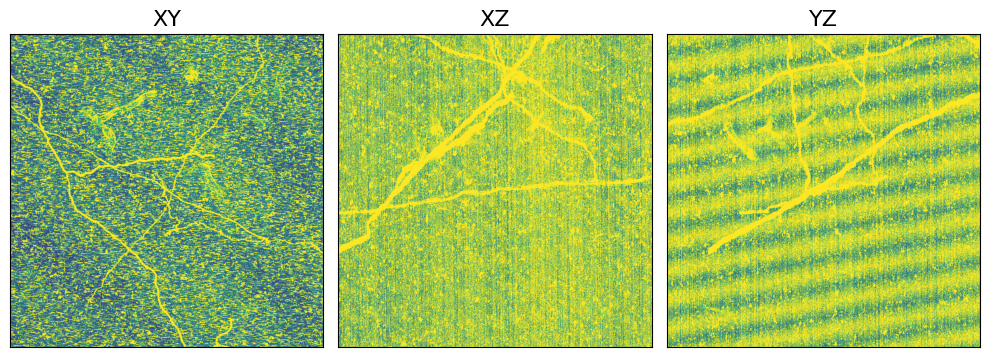

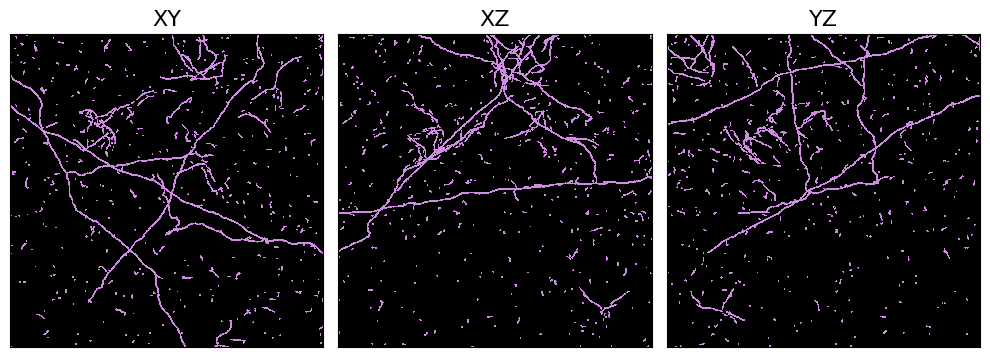

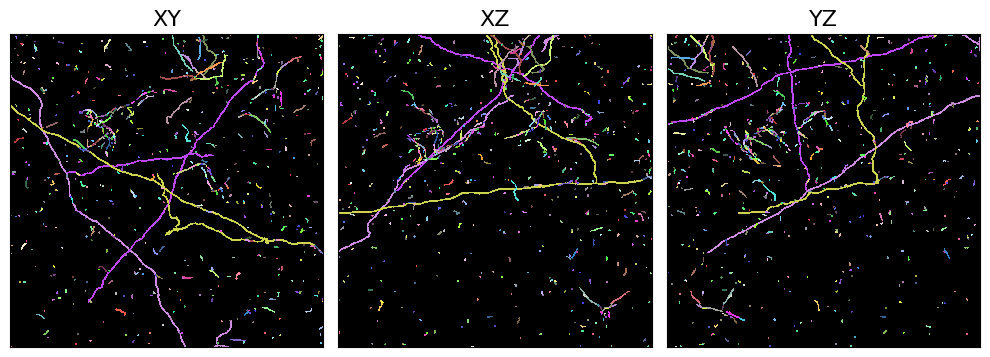

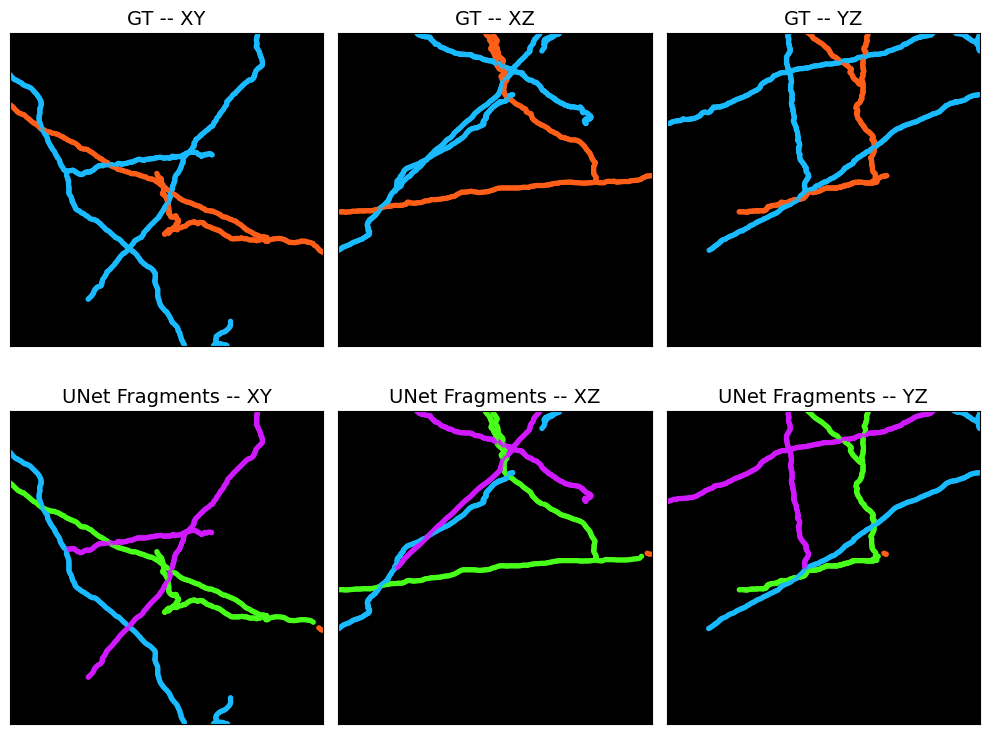


Figures saved to ../figs/


In [4]:
# Parameters
size_dim = 256
patch_shape = (size_dim, size_dim, size_dim) 
use_groundtruth = True

# Sample a center voxel from either GT or UNet fragments graph
src_graph = dataset.gt_graph if use_groundtruth else dataset.fragments_graph
node = util.sample_once(src_graph.nodes)
center_voxel = src_graph.node_voxel(node)

# Three data sources visualized below:
#
# 1. img_patch: Raw microscopy image (the actual brain scan)
#
# 2. seg_patch / seg_mask: UNet segmentation VOLUME — the model's per-voxel
#    prediction of which segment each voxel belongs to. Label 0 = background
#    (no neuron detected). This is what GT nodes are labeled against for
#    computing skeleton metrics.
#
# 3. Skeletons (two independent sets, plotted on separate rows):
#    - "GT" (Ground Truth): Manually traced neuron skeletons (the answer key).
#      19 neurons, from human-annotated SWC files.
#    - "UNet Fragments": Skeletons extracted FROM the UNet segmentation volume.
#      10,172 fragments — one skeleton per connected component in seg_patch.
#      These are NOT directly used in edge classification metrics; they are
#      only used for merge detection (checking if a single fragment spans
#      multiple GT neurons).

img_patch = dataset.img.read(center_voxel, patch_shape)
seg_patch = segmentation.read(center_voxel, patch_shape)
seg_mask = (seg_patch > 0).astype(int)

# Remap seg_patch to consecutive IDs for fast colormap creation.
# Raw segment IDs can be very large (e.g. 500000+), which makes
# make_segmentation_colormap allocate a huge array. Remapping to 0..N
# keeps the colormap small while preserving distinct colors per segment.
unique_ids, seg_patch_remapped = np.unique(seg_patch, return_inverse=True)
seg_patch_remapped = seg_patch_remapped.reshape(seg_patch.shape).astype(np.int32)

# Patch origin in global voxel space (for converting global -> local coords)
offset = tuple(c - s // 2 for c, s in zip(center_voxel, patch_shape))

# Find skeleton nodes + edges inside the patch.
gt_nodes, gt_node_comps = dataset.gt_graph.nodes_in_patch(
    offset, patch_shape, return_components=True
)
gt_edges, gt_edge_comps = dataset.gt_graph.edges_in_patch(
    offset, patch_shape, return_components=True
)
frag_nodes, frag_node_comps = dataset.fragments_graph.nodes_in_patch(
    offset, patch_shape, return_components=True
)
frag_edges, frag_edge_comps = dataset.fragments_graph.edges_in_patch(
    offset, patch_shape, return_components=True
)

# Segmentation volume stats in patch
n_seg_ids = len(unique_ids[unique_ids > 0])  # Exclude background (0)
seg_voxels = np.sum(seg_patch > 0)
total_voxels = np.prod(patch_shape)

print(f"GT nodes / edges / components in patch:        "
      f"{len(gt_nodes)} / {len(gt_edges)} / {len(np.unique(gt_node_comps))}")
print(f"Fragment nodes / edges / components in patch:  "
      f"{len(frag_nodes)} / {len(frag_edges)} / {len(np.unique(frag_node_comps))}")
print(f"Seg volume: {n_seg_ids} unique segment IDs, "
      f"{seg_voxels:,} labeled voxels / {total_voxels:,} total "
      f"({seg_voxels/total_voxels*100:.1f}% coverage)")

import matplotlib.pyplot as plt

# Save figures to figs/ directory
figs_dir = "../figs"
os.makedirs(figs_dir, exist_ok=True)

# Hook into matplotlib to save each figure before it's displayed.
# We monkey-patch plt.show temporarily to also call savefig.
_fig_counter = [0]
_fig_names = ["image_mip", "segmentation_binary_mip", "segmentation_color_mip", "skeleton_mip"]
_original_show = plt.show

def _saving_show(*args, **kwargs):
    fig = plt.gcf()
    name = _fig_names[_fig_counter[0]] if _fig_counter[0] < len(_fig_names) else f"fig_{_fig_counter[0]}"
    fig.savefig(os.path.join(figs_dir, f"{name}.png"), dpi=150, bbox_inches="tight")
    _fig_counter[0] += 1
    _original_show(*args, **kwargs)

plt.show = _saving_show

# Plot 1: Raw image MIP
img_util.plot_mips(img_patch)
# Plot 2: UNet segmentation volume (binary mask: segment vs background)
img_util.plot_segmentation_mips(seg_mask)
# Plot 3: UNet segmentation volume — each segment ID shown as a different color.
# This is the VOLUME that determines split/omit metrics (not the fragment skeletons).
# Different colors = different segments. If a GT neuron crosses a color boundary,
# that's a split error. Uses remapped IDs for fast rendering.
img_util.plot_segmentation_mips(seg_patch_remapped)
# Plot 4: Skeletons — GT (human-traced) and UNet fragments (auto-extracted)
# on separate rows. Each connected component gets its own color.
# UNet fragments are skeletons extracted FROM seg_patch — they correspond to
# the colored regions above, but colors won't match (independent palettes).
img_util.plot_skeleton_mips(
    {
        "GT": {
            "nodes": gt_nodes,
            "node_components": gt_node_comps,
            "edges": gt_edges,
            "components": gt_edge_comps,
            "color": "lime",
        },
        "UNet Fragments": {
            "nodes": frag_nodes,
            "node_components": frag_node_comps,
            "edges": frag_edges,
            "components": frag_edge_comps,
            "color": "cyan",
        },
    },
    patch_shape,
    separate_rows=True,
)

# Restore original plt.show
plt.show = _original_show
print(f"\nFigures saved to {figs_dir}/")

### Approximate the segmentation mask from skeletons (no cloud read)

Instead of reading the dense segmentation volume from the cloud (`segmentation.read(...)`),
we can **approximate** it directly from the fragment skeletons we already have in
memory (loaded from the cached graph). The idea:

1. Take the UNet fragment skeleton edges that fall inside the patch
   (`frag_edges`, already in local voxel coords).
2. **Rasterize** each edge into a zeroed patch volume using `make_digital_line`
   (draws the 1-voxel-thin center-line between the two endpoints).
3. **Dilate** the thin center-lines so they roughly fill the neuron's volume,
   approximating the segmentation footprint.

This is a *good but imperfect* approximation of the true segmentation — the main
advantage is that it avoids a cloud read entirely. Below we build the approximate
mask and plot it next to the real `seg_mask` (the cloud read) so you can compare.

> Alternatively, the same thing can be done with a **KDTree ball query**: take a
> voxel and query a KDTree of all fragment nodes for points within a radius, which
> returns the skeletons intersecting the region of interest. Here we already have
> the in-patch edges via `edges_in_patch`, so we rasterize those directly.

Skeleton-approximated mask vs. true segmentation mask
True (cloud read) labeled voxels:   377,406
Approx (from skeletons) voxels:      117,884
Intersection / Union (IoU):          0.243
Fragment edges rasterized:           1,005


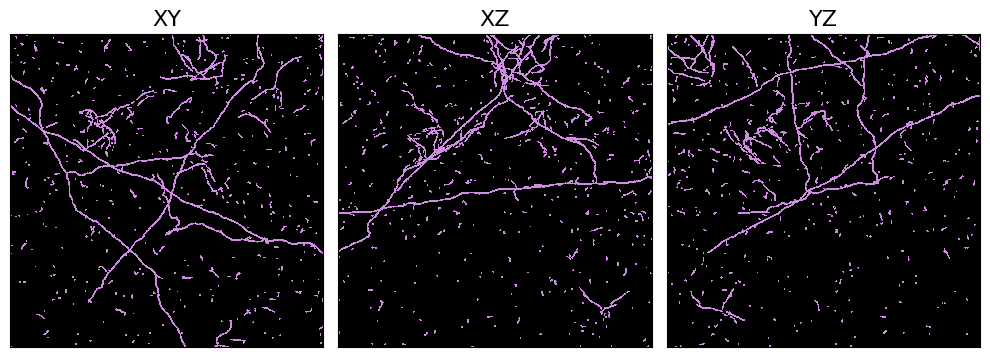

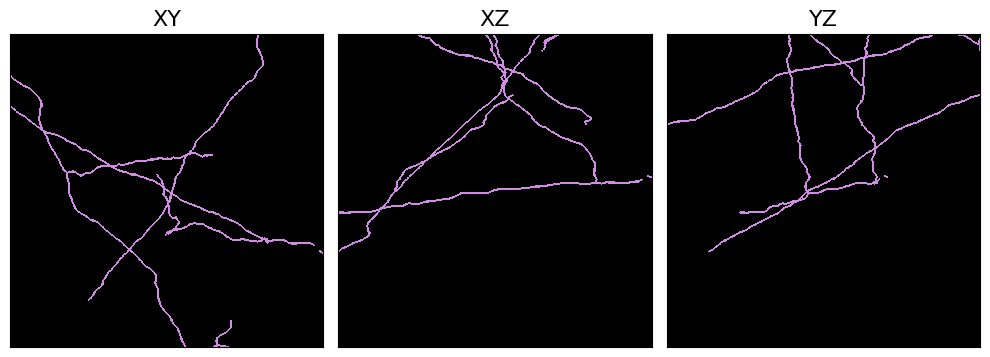

In [5]:
from scipy import ndimage

from agentic_neuron_proofreader.utils import geometry_util


def skeleton_mask_from_edges(edges, patch_shape, dilation_radius=3):
    """
    Approximates a segmentation mask by rasterizing skeleton edges into a
    zeroed patch volume and dilating the resulting center-lines.

    Parameters
    ----------
    edges : numpy.ndarray
        Array of shape (E, 2, 3): each edge as [start, end] in local (z, y, x)
        voxel coordinates relative to the patch origin (as returned by
        SkeletonGraph.edges_in_patch).
    patch_shape : Tuple[int]
        Patch size in voxels, in (z, y, x) order.
    dilation_radius : int, optional
        Radius (in voxels) used to dilate the thin skeleton lines so they
        roughly fill the neuron volume. Default is 3.

    Returns
    -------
    numpy.ndarray
        Binary mask of shape patch_shape approximating the segmentation.
    """
    mask = np.zeros(patch_shape, dtype=bool)
    upper = np.array(patch_shape) - 1

    # Step 1 + 2: rasterize each edge into a 1-voxel-thin center-line
    for start, end in edges:
        line = geometry_util.make_digital_line(
            np.round(start).astype(int), np.round(end).astype(int)
        )
        line = np.clip(line, 0, upper)
        mask[line[:, 0], line[:, 1], line[:, 2]] = True

    # Step 3: dilate the thin lines to approximate the neuron's volume
    if dilation_radius > 0 and mask.any():
        structure = ndimage.generate_binary_structure(3, 1)
        mask = ndimage.binary_dilation(
            mask, structure=structure, iterations=dilation_radius
        )
    return mask.astype(int)


# Build the approximate mask from the UNet fragment skeletons (no cloud read).
approx_mask = skeleton_mask_from_edges(frag_edges, patch_shape, dilation_radius=3)

# Compare coverage against the real segmentation mask (the cloud read).
true_voxels = int(np.sum(seg_mask > 0))
approx_voxels = int(np.sum(approx_mask > 0))
intersection = int(np.sum((seg_mask > 0) & (approx_mask > 0)))
union = int(np.sum((seg_mask > 0) | (approx_mask > 0)))
iou = intersection / union if union > 0 else float("nan")

print("Skeleton-approximated mask vs. true segmentation mask")
print("=" * 60)
print(f"True (cloud read) labeled voxels:   {true_voxels:,}")
print(f"Approx (from skeletons) voxels:      {approx_voxels:,}")
print(f"Intersection / Union (IoU):          {iou:.3f}")
print(f"Fragment edges rasterized:           {len(frag_edges):,}")

# Plot: true mask (top) vs. skeleton-approximated mask (bottom).
# Plot 5: True segmentation binary mask (from cloud read) -- the reference.
img_util.plot_segmentation_mips(seg_mask)
# Plot 6: Approximate mask built from fragment skeletons + dilation (no cloud read).
img_util.plot_segmentation_mips(approx_mask)


In [6]:
# import plotly.graph_objects as go
# import colorsys

# def plot_segmentation_3d(seg_remapped, original_ids, downsample=4,
#                          save_path="../figs/segmentation_3d.html"):
#     """
#     Interactive 3D plot of segmentation volume. Each segment shown as a
#     different color. Saves as an HTML file that can be opened in a browser.

#     Parameters
#     ----------
#     seg_remapped : ndarray
#         Segmentation volume with consecutive integer labels (0 = background).
#     original_ids : ndarray
#         Mapping from remapped IDs back to original segment IDs (from np.unique).
#     downsample : int
#         Downsample factor to reduce point count for performance.
#     save_path : str
#         Path to save the interactive HTML file.
#     """
#     # Downsample to keep point count manageable
#     seg_ds = seg_remapped[::downsample, ::downsample, ::downsample]

#     # Get non-background voxel coordinates and their labels
#     mask = seg_ds > 0
#     coords = np.argwhere(mask)  # (N, 3) in (z, y, x)
#     labels = seg_ds[mask]

#     # Generate distinct colors per segment
#     unique_labels = np.unique(labels)
#     n_labels = len(unique_labels)
#     colors_rgb = [colorsys.hsv_to_rgb(i / max(n_labels, 1), 0.9, 1.0)
#                   for i in range(n_labels)]
#     label_to_color = {int(lbl): colors_rgb[i] for i, lbl in enumerate(unique_labels)}

#     point_colors = [
#         f"rgb({int(label_to_color[int(l)][0]*255)},"
#         f"{int(label_to_color[int(l)][1]*255)},"
#         f"{int(label_to_color[int(l)][2]*255)})"
#         for l in labels
#     ]

#     hover_text = [f"Segment {original_ids[int(l)]}" for l in labels]

#     fig = go.Figure(data=[go.Scatter3d(
#         x=coords[:, 2],  # x
#         y=coords[:, 1],  # y
#         z=coords[:, 0],  # z
#         mode='markers',
#         marker=dict(size=1.5, color=point_colors, opacity=0.6),
#         text=hover_text,
#         hoverinfo='text',
#     )])

#     fig.update_layout(
#         title="3D Segmentation Volume (interactive)",
#         scene=dict(
#             xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
#             bgcolor="black",
#         ),
#         paper_bgcolor="black",
#         font=dict(color="white"),
#         width=900, height=700,
#     )

#     os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else ".", exist_ok=True)
#     fig.write_html(save_path)
#     print(f"3D segmentation saved to {save_path}")
#     print(f"  Points plotted: {len(coords):,} (downsample={downsample}x)")
#     print(f"  Segments: {n_labels}")
#     fig.show()

# plot_segmentation_3d(seg_patch_remapped, unique_ids, downsample=1,
#                      save_path="../figs/segmentation_3d.html")

### Patch-local Skeleton Metrics

**IMPORTANT DISTINCTION from the cell below:**

The next section shows **whole-brain metrics** for skeletons that have nodes in this patch. Those split/merge errors could have occurred anywhere in the brain, not necessarily in this patch.

This cell computes **patch-local metrics** — only counting errors that are actually visible in the current patch. Uses the **identical** edge classification logic as `segmentation_skeleton_metrics.skeleton_metrics`:

- **Split edge**: GT edge where the two endpoint labels differ AND both labels are non-empty (includes one endpoint in background "0" and the other in a segment — this counts as a split, not an omit!)
- **Omit edge**: GT edge where **BOTH** endpoints have label "0" (background)
- **Correct edge**: GT edge where both endpoints have the same non-empty label
- **Merge**: A UNet segment that contains GT nodes from >1 distinct GT skeleton (with >50 nodes from each, matching the metrics package threshold)
- **Edge Accuracy**: `100 - (% Split + % Omit + % Merged)` (same formula as `EdgeAccuracyMetric`)

This shows the actual segmentation quality within this specific patch.

In [7]:
from collections import defaultdict

# This follows the EXACT same edge classification logic as
# segmentation_skeleton_metrics.skeleton_metrics (SplitEdgePercentMetric,
# OmitEdgePercentMetric, MergedEdgePercentMetric, EdgeAccuracyMetric).
# Operates only on the current patch instead of the whole brain.

# Step 1: Get GT nodes in patch and label them with UNet segment IDs
# (Same as _label_graph() in graph_loading.py — labels each GT node by
# reading the segmentation at its voxel coordinate)
gt_local, gt_ids = dataset.gt_graph.nodes_in_patch(
    offset, patch_shape, return_ids=True
)

gt_local_int = np.round(gt_local).astype(int)
gt_local_int = np.clip(gt_local_int, 0, np.array(patch_shape) - 1)

# Label each GT node with its UNet segment ID (as string, matching the package)
gt_node_labels = seg_patch[
    gt_local_int[:, 0], gt_local_int[:, 1], gt_local_int[:, 2]
]
# Convert to string labels to match segmentation_skeleton_metrics convention
# where "0" = background, any other string = segment ID
gt_node_label_str = [str(int(lbl)) for lbl in gt_node_labels]

id_to_idx = {int(nid): i for i, nid in enumerate(gt_ids)}

# Step 2: Classify edges — EXACTLY matching the metrics package logic:
#
# From skeleton_metrics.py:
#   SplitEdgePercentMetric.count_split_edges (line 146-151):
#     is_different = graph.node_label[i] != graph.node_label[j]
#     is_nonzero = graph.node_label[i] and graph.node_label[j]
#     split if is_different AND is_nonzero
#
#   OmitEdgePercentMetric.count_omit_edges (line 211-215):
#     omit if graph.node_label[i] == "0" AND graph.node_label[j] == "0"
#
# Key: "0" is a truthy string in Python, so an edge with one endpoint "0"
# and the other a segment ID counts as SPLIT (not omit). Omit requires BOTH
# endpoints to be "0".

n_correct = n_split = n_omit = 0

for u, v in dataset.gt_graph.edges():
    if u in id_to_idx and v in id_to_idx:
        lu = gt_node_label_str[id_to_idx[u]]
        lv = gt_node_label_str[id_to_idx[v]]

        if lu == "0" and lv == "0":
            # Both endpoints in background → omit
            n_omit += 1
        elif lu != lv and lu and lv:
            # Different labels, both non-empty → split
            # (includes "0" vs "12345" since "0" is truthy)
            n_split += 1
        else:
            # Same non-empty label → correct
            n_correct += 1

# Step 3: Count merges — matching MergedEdgePercentMetric.detect_label_intersections
# A UNet segment is a "merge" if GT nodes from >1 GT component land on it,
# AND each component contributes >50 nodes (same threshold as the package,
# see skeleton_metrics.py line 293).
seg_to_components = defaultdict(lambda: defaultdict(int))
gt_comp = dataset.gt_graph.node_component_id

for i, nid in enumerate(gt_ids):
    label = gt_node_label_str[i]
    if label != "0":
        comp_id = int(gt_comp[int(nid)])
        seg_to_components[label][comp_id] += 1

# Count merged edges: edges where both endpoints share a label that is a merge
labels_with_merge = set()
for label, comp_counts in seg_to_components.items():
    # A merge requires >1 component with >50 nodes each in the same segment
    large_components = [c for c, cnt in comp_counts.items() if cnt > 50]
    if len(large_components) > 1:
        labels_with_merge.add(label)

n_merged_edges = 0
for u, v in dataset.gt_graph.edges():
    if u in id_to_idx and v in id_to_idx:
        lu = gt_node_label_str[id_to_idx[u]]
        lv = gt_node_label_str[id_to_idx[v]]
        if lu == lv and lu in labels_with_merge:
            n_merged_edges += 1

n_merges = len(labels_with_merge)

# Step 4: Compute derived metrics — matching EdgeAccuracyMetric (line 779-784):
#   edge_accuracy = 100 - (% Split + % Omit + % Merged)
n_edges = n_correct + n_split + n_omit

if n_edges > 0:
    pct_split = (n_split / n_edges) * 100
    pct_omit = (n_omit / n_edges) * 100
    pct_merged = (n_merged_edges / n_edges) * 100
    edge_accuracy = 100 - (pct_split + pct_omit + pct_merged)
else:
    pct_split = pct_omit = pct_merged = edge_accuracy = float('nan')

# Display results
print("Patch-local Skeleton Metrics (errors visible in this patch only)")
print("=" * 70)
print(f"GT nodes in patch:           {len(gt_ids)}")
print(f"GT edges fully in patch:     {n_edges}")
print()
print("Edge Classification:")
if n_edges > 0:
    print(f"  Correct:  {n_correct:4d}  ({n_correct/n_edges*100:5.1f}%)")
    print(f"  Split:    {n_split:4d}  ({pct_split:5.1f}%)")
    print(f"  Omit:     {n_omit:4d}  ({pct_omit:5.1f}%)")
    print(f"  Merged:   {n_merged_edges:4d}  ({pct_merged:5.1f}%)")
else:
    print("  No edges in patch.")
print()
print(f"Merge segments (>1 GT component with >50 nodes each): {n_merges}")
print()
if n_edges > 0:
    print(f"Edge Accuracy:    {edge_accuracy:.2f}%")
    print(f"% Split Edges:    {pct_split:.2f}%")
    print(f"% Omit Edges:     {pct_omit:.2f}%")
    print(f"% Merged Edges:   {pct_merged:.2f}%")
print()
print("Note: This shows only errors visible in the current patch,")
print("      unlike the whole-brain metrics shown below.")

Patch-local Skeleton Metrics (errors visible in this patch only)
GT nodes in patch:           1117
GT edges fully in patch:     1113

Edge Classification:
  Correct:  1062  ( 95.4%)
  Split:      41  (  3.7%)
  Omit:       10  (  0.9%)
  Merged:      0  (  0.0%)

Merge segments (>1 GT component with >50 nodes each): 0

Edge Accuracy:    95.42%
% Split Edges:    3.68%
% Omit Edges:     0.90%
% Merged Edges:   0.00%

Note: This shows only errors visible in the current patch,
      unlike the whole-brain metrics shown below.


Edges by type:  correct=1062  split=41  omit=10  merged=0
Nodes by type:  correct=1048  split=46  omit=23  merged=0


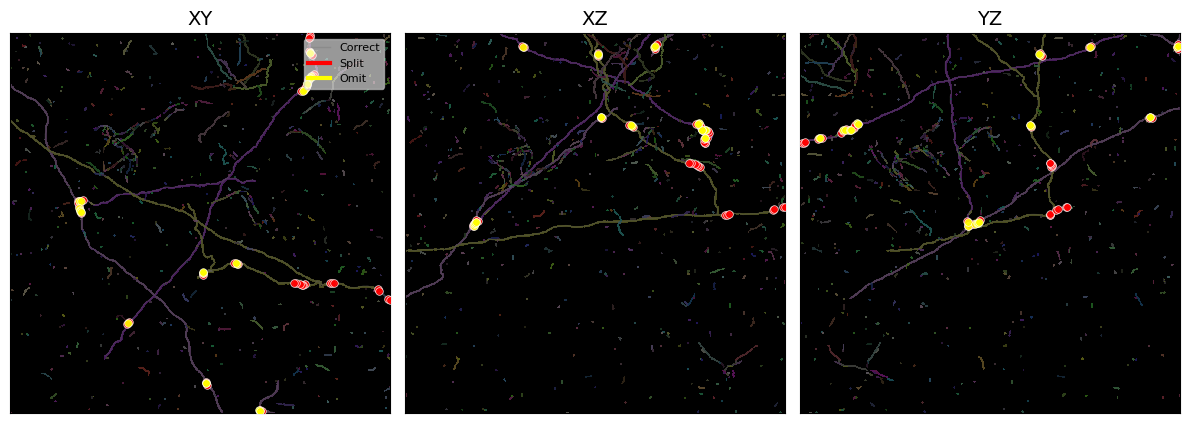

Error visualization saved to ../figs/skeleton_errors_mip.png


In [8]:
# Visualize GT edges and nodes with errors highlighted.
# Collect edges and nodes by classification type using local patch coordinates.

correct_edges = []
split_edges = []
omit_edges = []
merged_edges = []

# Classify nodes: a node is colored by its segment label
correct_nodes = []
split_nodes = []  # nodes involved in a split edge (label != neighbor's label)
omit_nodes = []   # nodes with label "0"
merged_nodes = [] # nodes with a merge label

# First, classify nodes by their own label
node_is_error = np.zeros(len(gt_ids), dtype=int)  # 0=correct, 1=split, 2=omit, 3=merged
for i, nid in enumerate(gt_ids):
    label = gt_node_label_str[i]
    if label == "0":
        node_is_error[i] = 2  # omit
    elif label in labels_with_merge:
        node_is_error[i] = 3  # merged

# Mark nodes involved in split edges
for u, v in dataset.gt_graph.edges():
    if u in id_to_idx and v in id_to_idx:
        lu = gt_node_label_str[id_to_idx[u]]
        lv = gt_node_label_str[id_to_idx[v]]
        edge_coords = np.array([gt_local[id_to_idx[u]], gt_local[id_to_idx[v]]])

        if lu == "0" and lv == "0":
            omit_edges.append(edge_coords)
        elif lu != lv and lu and lv:
            split_edges.append(edge_coords)
            # Mark both endpoints as involved in a split
            if node_is_error[id_to_idx[u]] == 0:
                node_is_error[id_to_idx[u]] = 1
            if node_is_error[id_to_idx[v]] == 0:
                node_is_error[id_to_idx[v]] = 1
        elif lu == lv and lu in labels_with_merge:
            merged_edges.append(edge_coords)
        else:
            correct_edges.append(edge_coords)

# Collect nodes by type
for i in range(len(gt_ids)):
    if node_is_error[i] == 0:
        correct_nodes.append(gt_local[i])
    elif node_is_error[i] == 1:
        split_nodes.append(gt_local[i])
    elif node_is_error[i] == 2:
        omit_nodes.append(gt_local[i])
    elif node_is_error[i] == 3:
        merged_nodes.append(gt_local[i])

correct_edges = np.array(correct_edges) if correct_edges else np.empty((0, 2, 3))
split_edges = np.array(split_edges) if split_edges else np.empty((0, 2, 3))
omit_edges = np.array(omit_edges) if omit_edges else np.empty((0, 2, 3))
merged_edges = np.array(merged_edges) if merged_edges else np.empty((0, 2, 3))

correct_nodes = np.array(correct_nodes) if correct_nodes else np.empty((0, 3))
split_nodes = np.array(split_nodes) if split_nodes else np.empty((0, 3))
omit_nodes = np.array(omit_nodes) if omit_nodes else np.empty((0, 3))
merged_nodes = np.array(merged_nodes) if merged_nodes else np.empty((0, 3))

print(f"Edges by type:  correct={len(correct_edges)}  split={len(split_edges)}  "
      f"omit={len(omit_edges)}  merged={len(merged_edges)}")
print(f"Nodes by type:  correct={len(correct_nodes)}  split={len(split_nodes)}  "
      f"omit={len(omit_nodes)}  merged={len(merged_nodes)}")

# Improved error visualization:
#   - Segmentation MIP as semi-transparent background (shows WHY errors occur)
#   - Correct edges dimmed to gray context lines
#   - Error edges highlighted with colored halos
#   - Error nodes drawn with white outlines for visibility
error_groups = {}
if len(split_edges) > 0 or len(split_nodes) > 0:
    error_groups["Split"] = {"nodes": split_nodes, "edges": split_edges, "color": "red"}
if len(omit_edges) > 0 or len(omit_nodes) > 0:
    error_groups["Omit"] = {"nodes": omit_nodes, "edges": omit_edges, "color": "yellow"}
if len(merged_edges) > 0 or len(merged_nodes) > 0:
    error_groups["Merged"] = {"nodes": merged_nodes, "edges": merged_edges, "color": "magenta"}

seg_cmap = img_util.make_segmentation_colormap(seg_patch_remapped)

_original_show = plt.show
def _save_error_fig(*args, **kwargs):
    fig = plt.gcf()
    fig.savefig(os.path.join(figs_dir, "skeleton_errors_mip.png"), dpi=150, bbox_inches="tight")
    _original_show(*args, **kwargs)
plt.show = _save_error_fig

img_util.plot_skeleton_errors(
    correct_edges,
    error_groups,
    patch_shape,
    seg_patch=seg_patch_remapped,
    seg_cmap=seg_cmap,
)

plt.show = _original_show
print(f"Error visualization saved to {figs_dir}/skeleton_errors_mip.png")

### Zoomed view of local split-error sites

The `skeleton_errors_mip` figure above projects the *whole* patch, so individual split errors are hard to inspect. This cell picks **3 well-separated** split sites (greedily, so the rows show different errors rather than three crops of the same cluster) and renders each as a zoomed-in crop in a 3x3 grid:

- **rows** = 3 different split sites (subfields to zoom into),
- **columns** = the **XY / XZ / YZ** maximum-intensity-projection views of the same `RF`-voxel **receptive field** centered on that site.

Each panel shows the **raw image** (grayscale) with a faint **segmentation** overlay and the **split edge(s)** in red. Where the red edge crosses a gap in the raw signal or a segment-color boundary, you can see *why* the U-Net split the neuron there.

Found 41 split edges; showing 3 well-separated split sites in 96-voxel windows (rows=sites, cols=XY/XZ/YZ).


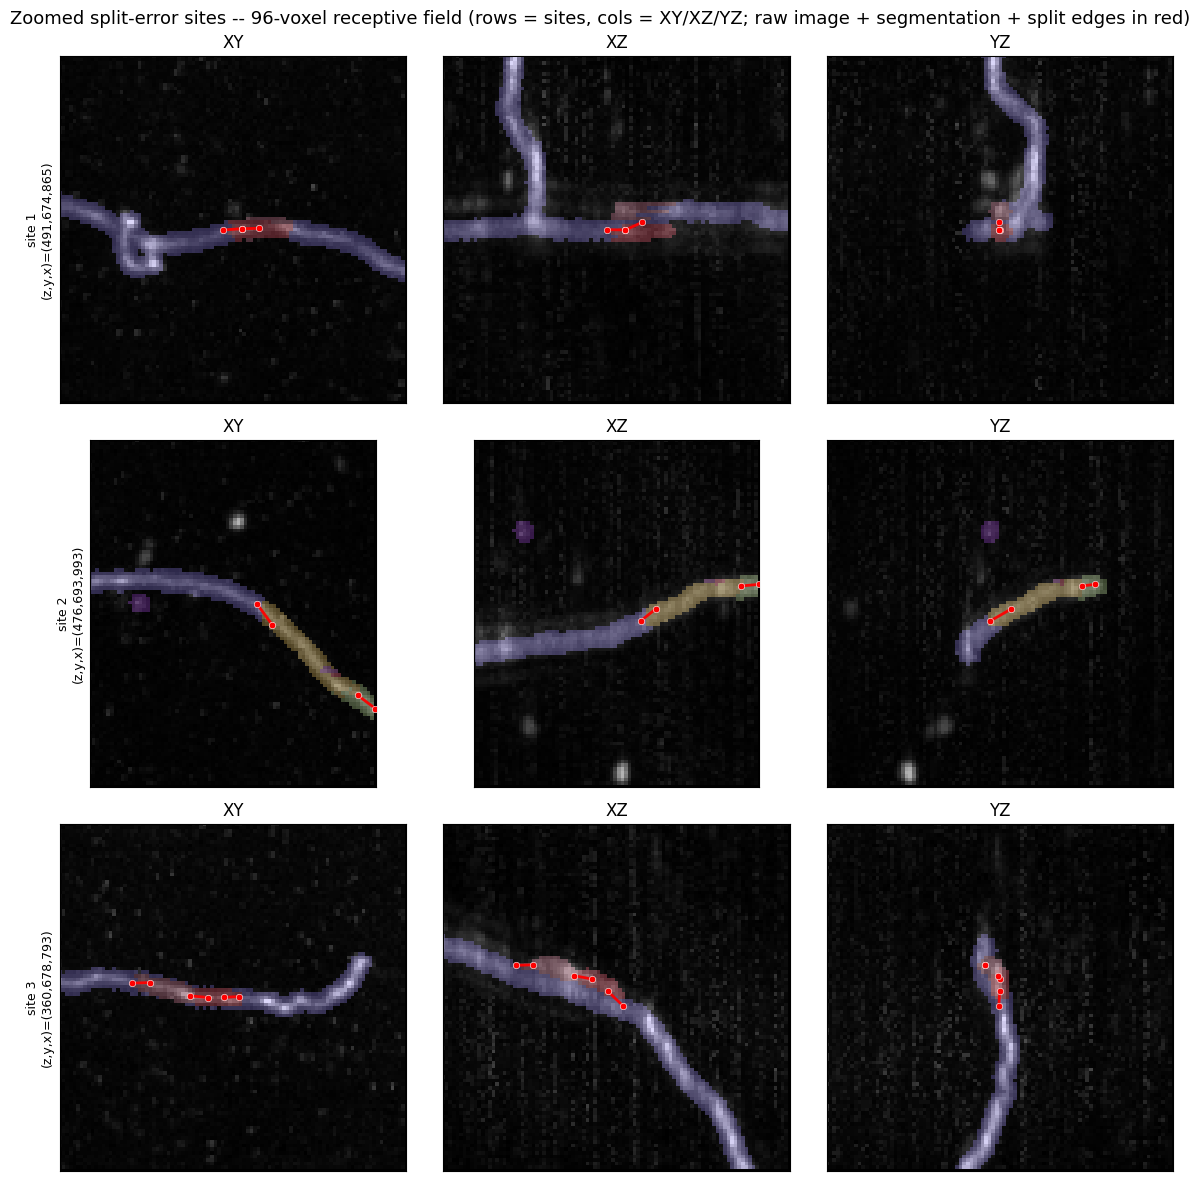

Zoomed split-site view saved to ../figs/skeleton_split_sites_zoom.png


In [9]:
# Zoomed 3x3 view of local split-error sites.
# Rows = 3 different split sites; columns = XY / XZ / YZ views of that site.
# Reuses split_edges / img_patch / seg_patch_remapped / seg_cmap / patch_shape
# computed in the skeleton-errors cell above.

import matplotlib.pyplot as plt
import numpy as np

RF = 96                 # receptive-field size (voxels) of each zoom window
half = RF // 2
n_sites = 3             # rows: different split sites

# Three projection views. For an array in (z, y, x) order, projecting along
# `proj` collapses that axis; the remaining two axes (row, col) define the
# plane. row -> vertical (y-axis of plot), col -> horizontal (x-axis of plot).
views = [
    ('XY', 0, 1, 2),    # project z -> rows=y, cols=x
    ('XZ', 1, 0, 2),    # project y -> rows=z, cols=x
    ('YZ', 2, 0, 1),    # project x -> rows=z, cols=y
]

# Candidate centers = midpoints of split edges, in local (z, y, x) voxels.
split_mids = split_edges.mean(axis=1) if len(split_edges) else np.empty((0, 3))

# Greedily pick well-separated centers so the rows show DIFFERENT split sites
# instead of three near-identical crops of one cluster.
def pick_spread(points, k, min_sep):
    chosen = []
    for p in points:
        if all(np.linalg.norm(p - c) >= min_sep for c in chosen):
            chosen.append(p)
        if len(chosen) >= k:
            break
    return chosen

centers = pick_spread(split_mids, n_sites, min_sep=half) if len(split_mids) else []

if not centers:
    print('No split-edge sites in this patch -- nothing to zoom into. '
          'Try a different center_voxel / larger patch_shape, or a patch that '
          'actually contains split errors.')
else:
    print(f'Found {len(split_mids)} split edges; showing {len(centers)} '
          f'well-separated split sites in {RF}-voxel windows '
          f'(rows=sites, cols=XY/XZ/YZ).')

    fig, axs = plt.subplots(n_sites, 3, figsize=(12, 4 * n_sites), squeeze=False)

    for r in range(n_sites):
        # Window bounds for this site, clamped to the patch (shared across views).
        if r < len(centers):
            cz, cy, cx = (int(round(v)) for v in centers[r])
            lo = [max(c - half, 0) for c in (cz, cy, cx)]
            hi = [min(c + half, patch_shape[ax]) for ax, c in enumerate((cz, cy, cx))]
            # Split edges whose midpoint falls inside this 3D window.
            m = split_mids
            inwin = np.ones(len(m), dtype=bool)
            for ax in range(3):
                inwin &= (m[:, ax] >= lo[ax]) & (m[:, ax] < hi[ax])
            site_edges = split_edges[inwin]
        else:
            cz = cy = cx = None

        for ci, (name, proj, a, b) in enumerate(views):
            ax = axs[r, ci]
            ax.set_facecolor('black')
            ax.set_xticks([]); ax.set_yticks([])

            if r >= len(centers):
                ax.set_title('(no more split sites)', fontsize=9, color='gray')
                continue

            # Crop the shared 3D window, then MIP along this view's proj axis.
            sl = tuple(slice(lo[k], hi[k]) for k in range(3))
            img_mip = np.max(img_patch[sl], axis=proj)
            ax.imshow(img_mip, cmap='gray', interpolation='none')

            seg_mip = np.max(seg_patch_remapped[sl], axis=proj)
            ax.imshow(seg_mip, cmap=seg_cmap, interpolation='none', alpha=0.3)

            # Overlay split edges, projected onto this view's (a, b) plane and
            # shifted into local window coordinates.
            for e in site_edges:
                rows_coord = e[:, a] - lo[a]   # vertical (plot y)
                cols_coord = e[:, b] - lo[b]   # horizontal (plot x)
                ax.plot(cols_coord, rows_coord, color='red', linewidth=2.0, alpha=0.95)
                ax.scatter(cols_coord, rows_coord, s=22, c='red',
                           edgecolors='white', linewidths=0.4, zorder=5)

            ax.set_xlim(0, hi[b] - lo[b])
            ax.set_ylim(hi[a] - lo[a], 0)
            ax.set_aspect('equal')
            if ci == 0:
                ax.set_ylabel(f'site {r + 1}\n(z,y,x)=({cz},{cy},{cx})', fontsize=9)
            ax.set_title(name, fontsize=12)

    fig.suptitle(
        f'Zoomed split-error sites -- {RF}-voxel receptive field '
        f'(rows = sites, cols = XY/XZ/YZ; raw image + segmentation + split edges in red)',
        fontsize=13,
    )
    plt.tight_layout()
    fig.savefig(os.path.join(figs_dir, 'skeleton_split_sites_zoom.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Zoomed split-site view saved to {figs_dir}/skeleton_split_sites_zoom.png')


### Reference figure: where the zoom sites are

Same as `skeleton_errors_mip`, but with a numbered box drawn around each of the 3 receptive-field windows that the zoomed view above crops into, in all three XY / XZ / YZ projections. Use it as a key: box *N* here is **site *N*** in `skeleton_split_sites_zoom`. Saved to `skeleton_errors_mip_boxed.png`.

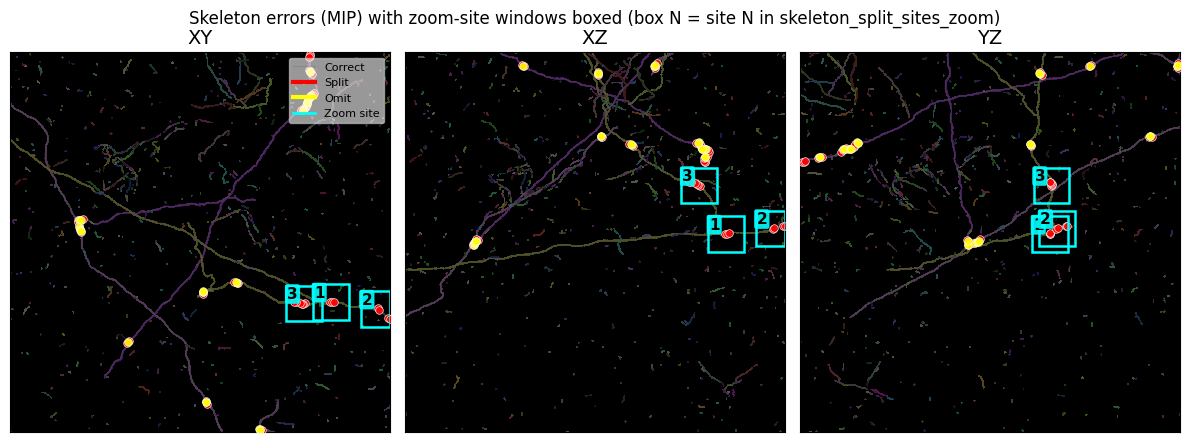

Reference figure saved to ../figs/skeleton_errors_mip_boxed.png


In [10]:
# Reference figure: skeleton_errors_mip with the 3 zoom windows boxed.
# Mirrors img_util.plot_skeleton_errors panel geometry exactly, then overlays a
# numbered rectangle for each window the zoom cell crops into, so you can see
# which part of the patch each zoom row (site) corresponds to.
# Reuses correct_edges / error_groups / patch_shape / seg_patch_remapped /
# seg_cmap from the errors cell and centers / RF / half from the zoom cell.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

if not centers:
    print('No zoom sites were selected (no split edges) -- nothing to box.')
else:
    axs_names = ['XY', 'XZ', 'YZ']
    plane_axes = [(1, 2), (0, 2), (0, 1)]   # (a=row/vertical, b=col/horizontal)
    box_color = 'cyan'

    fig, axs = plt.subplots(1, 3, figsize=(12, 4.5))

    for i, (name, (a, b)) in enumerate(zip(axs_names, plane_axes)):
        ax = axs[i]
        ax.set_facecolor('black')

        # Background: segmentation MIP (semi-transparent) -- same as the errors fig.
        seg_mip = np.max(seg_patch_remapped, axis=i)
        ax.imshow(seg_mip, cmap=seg_cmap, interpolation='none', alpha=0.35)

        # Correct edges: thin, low-alpha gray context lines.
        if len(correct_edges):
            segs = np.stack(
                [correct_edges[:, 0, [b, a]], correct_edges[:, 1, [b, a]]], axis=1
            )
            ax.add_collection(
                LineCollection(segs, colors=(0.4, 0.4, 0.4, 0.3), linewidths=1.0)
            )

        # Error edges (halo + solid) and nodes.
        for label, group in error_groups.items():
            edges = group.get('edges', np.empty((0, 2, 3)))
            nodes = group.get('nodes', np.empty((0, 3)))
            color = group['color']
            if len(edges):
                segs = np.stack([edges[:, 0, [b, a]], edges[:, 1, [b, a]]], axis=1)
                ax.add_collection(LineCollection(segs, colors=color, linewidths=6.0, alpha=0.25))
                ax.add_collection(LineCollection(segs, colors=color, linewidths=2.5, alpha=1.0))
            if len(nodes):
                ax.scatter(nodes[:, b], nodes[:, a], s=30, c=color,
                           edgecolors='white', linewidths=0.5, alpha=0.9, zorder=5)

        # The zoom windows: one numbered box per site, using the SAME clamped
        # bounds the zoom cell computes (half-window around each center).
        for r, center in enumerate(centers):
            cz, cy, cx = (int(round(v)) for v in center)
            lo = [max(c - half, 0) for c in (cz, cy, cx)]
            hi = [min(c + half, patch_shape[ax3]) for ax3, c in enumerate((cz, cy, cx))]
            x0, x1 = lo[b], hi[b]
            y0, y1 = lo[a], hi[a]
            ax.add_patch(Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                fill=False, edgecolor=box_color, linewidth=1.8, zorder=6,
            ))
            ax.text(x0 + 2, y0 + 2, str(r + 1), color='black', fontsize=11,
                    fontweight='bold', va='top', ha='left', zorder=7,
                    bbox=dict(boxstyle='round,pad=0.15', fc=box_color, ec='none', alpha=0.9))

        ax.set_xlim(0, patch_shape[b])
        ax.set_ylim(patch_shape[a], 0)
        ax.set_aspect('equal')
        ax.set_title(name, fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])

    handles = [Line2D([0], [0], color='gray', linewidth=1, alpha=0.5, label='Correct')]
    for label, group in error_groups.items():
        handles.append(Line2D([0], [0], color=group['color'], linewidth=3, label=label))
    handles.append(Line2D([0], [0], color=box_color, linewidth=2, label='Zoom site'))
    axs[0].legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.6)

    fig.suptitle('Skeleton errors (MIP) with zoom-site windows boxed '
                 '(box N = site N in skeleton_split_sites_zoom)', fontsize=12)
    plt.tight_layout()
    fig.savefig(os.path.join(figs_dir, 'skeleton_errors_mip_boxed.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Reference figure saved to {figs_dir}/skeleton_errors_mip_boxed.png')


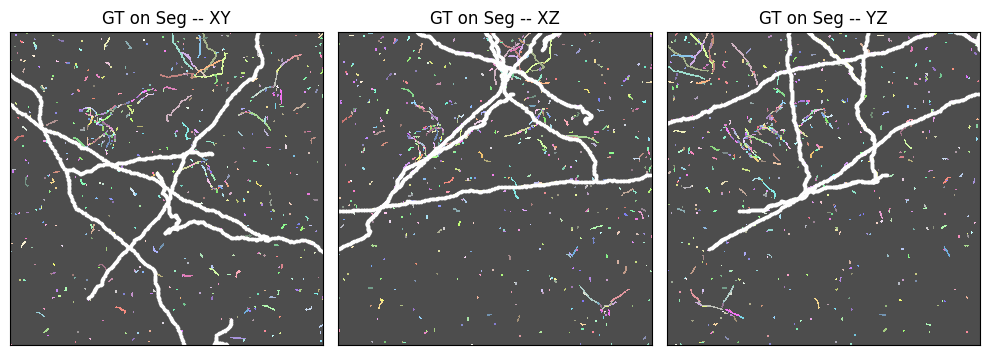

Overlay saved to ../figs/gt_on_segmentation_overlay.png


In [11]:
# Overlay GT skeleton on top of segmentation color MIP.
# This lets you visually verify: where the GT skeleton crosses a color boundary
# in the segmentation, you should see a split error in skeleton_errors_mip.
#
# Expected behavior:
# - GT skeleton should mostly run ALONG colored segments (correct)
# - Where the skeleton crosses from one color to another → split (red in errors plot)
# - Where the skeleton passes through black (background) → omit/split (yellow/red)
# - Colors WON'T match between the two layers (independent palettes)

from matplotlib.colors import ListedColormap

fig, axs = plt.subplots(1, 3, figsize=(10, 4))
axs_names = ["XY", "XZ", "YZ"]
plane_axes = [(1, 2), (0, 2), (0, 1)]

# Build colormap for segmentation (same as plot_segmentation_mips)
cmap = img_util.make_segmentation_colormap(seg_patch_remapped)

for i, (name, (a, b)) in enumerate(zip(axs_names, plane_axes)):
    ax = axs[i]
    
    # Draw segmentation color MIP as background
    seg_mip = np.max(seg_patch_remapped, axis=i)
    ax.imshow(seg_mip, cmap=cmap, interpolation="none", alpha=0.7)
    
    # Overlay GT skeleton edges (white for visibility on colored background)
    if len(gt_edges) > 0:
        from matplotlib.collections import LineCollection
        segs = np.stack([gt_edges[:, 0, [b, a]], gt_edges[:, 1, [b, a]]], axis=1)
        lc = LineCollection(segs, colors="white", linewidths=1.5, alpha=0.9)
        ax.add_collection(lc)
    
    # Overlay GT nodes
    if len(gt_nodes) > 0:
        ax.scatter(gt_nodes[:, b], gt_nodes[:, a], s=3, c="white", alpha=0.9)
    
    ax.set_xlim(0, patch_shape[b])
    ax.set_ylim(patch_shape[a], 0)
    ax.set_aspect("equal")
    ax.set_title(f"GT on Seg -- {name}", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, "gt_on_segmentation_overlay.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Overlay saved to {figs_dir}/gt_on_segmentation_overlay.png")

### Patch-level Skeleton Metrics

Loads pre-computed metrics from `evaluate_skeleton_metrics.ipynb` and displays
them in the context of the current patch. Shows which GT skeleton components
are present in the patch and reports the full-brain metrics (correct / split /
omit edges, merges, edge accuracy, etc.) from the evaluation output.

**Key features:**
- Uses pre-computed results from `metrics_out/{brain_id}/{segmentation_id}/results.csv`
- Identifies which GT component IDs fall within the current patch
- Displays per-skeleton metrics table and summary statistics
- No recomputation needed — leverages the full `segmentation-skeleton-metrics` pipeline

**Note:** Requires running `evaluate_skeleton_metrics.ipynb` first to generate the metrics CSV file.

In [12]:
import pandas as pd
import os

# Load the pre-computed metrics from evaluate_skeleton_metrics
metrics_dir = f"../metrics_out/{brain_id}/{segmentation_id}"
results_path = os.path.join(metrics_dir, "results.csv")

if not os.path.exists(results_path):
    print(f"Metrics file not found: {results_path}")
    print("Please run evaluate_skeleton_metrics.ipynb first to generate the metrics CSV file.")
else:
    # Load the per-skeleton metrics
    results_df = pd.read_csv(results_path, index_col=0)
    
    # Find which GT skeleton(s) are in the current patch
    gt_local, gt_ids = dataset.gt_graph.nodes_in_patch(
        offset, patch_shape, return_ids=True
    )
    
    # Get the component IDs for nodes in the patch
    gt_comp = dataset.gt_graph.node_component_id
    patch_component_ids = set(int(gt_comp[int(nid)]) for nid in gt_ids)
    
    print("Patch-level Skeleton Metrics")
    print("=" * 60)
    print(f"GT nodes in patch:         {len(gt_ids)}")
    print(f"GT components in patch:    {len(patch_component_ids)}")
    print(f"Component IDs in patch:    {sorted(patch_component_ids)}")
    print()
    
    if len(patch_component_ids) > 0:
        # Filter to only skeletons that have nodes in the patch
        # Match by position: component ID i corresponds to row i in results_df
        patch_rows = []
        for comp_id in sorted(patch_component_ids):
            if comp_id < len(results_df):
                patch_rows.append(comp_id)
        
        if len(patch_rows) > 0:
            patch_results = results_df.iloc[patch_rows]
            
            print("Metrics for GT skeletons in this patch:")
            print("-" * 60)
            print(patch_results)
            
            print("\n" + "=" * 60)
            print("Summary Statistics (patch skeletons only):")
            print("-" * 60)
            
            # Aggregate metrics
            avg_edge_accuracy = patch_results['Edge Accuracy'].mean()
            avg_split_rate = patch_results['Split Rate'].mean()
            avg_merge_rate = patch_results['Merge Rate'].mean()
            total_splits = patch_results['# Splits'].sum()
            total_merges = patch_results['# Merges'].sum()
            avg_pct_split = patch_results['% Split Edges'].mean()
            avg_pct_omit = patch_results['% Omit Edges'].mean()
            avg_pct_merged = patch_results['% Merged Edges'].mean()
            
            print(f"Number of skeletons:  {len(patch_results)}")
            print(f"Total splits:         {int(total_splits):,}")
            print(f"Total merges:         {int(total_merges):,}")
            print()
            print(f"Avg Edge Accuracy:    {avg_edge_accuracy:.2f}%")
            print(f"Avg Split Rate:       {avg_split_rate:.2f}")
            print(f"Avg Merge Rate:       {avg_merge_rate:.2f}")
            print()
            print(f"Avg % Split Edges:    {avg_pct_split:.2f}%")
            print(f"Avg % Omit Edges:     {avg_pct_omit:.2f}%")
            print(f"Avg % Merged Edges:   {avg_pct_merged:.2f}%")
        else:
            print("Could not match patch component IDs to CSV rows.")
    else:
        print("No GT nodes found in this patch.")

Patch-level Skeleton Metrics
GT nodes in patch:         1117
GT components in patch:    2
Component IDs in patch:    [10, 12]

Metrics for GT skeletons in this patch:
------------------------------------------------------------
                SWC Run Length  # Splits  # Merges  % Split Edges  \
N013-794495-PP   428938.019221     210.0         2       0.130291   
N015-794495-IG   150584.837316     100.0         1       0.151336   

                % Omit Edges  % Merged Edges      ERL  Normalized ERL  \
N013-794495-PP      0.487373       68.606315  1799.79          0.0042   
N015-794495-IG      2.766889        0.581639  1341.52          0.0089   

                Edge Accuracy  Split Rate  Merge Rate  
N013-794495-PP          30.78     2029.95   213144.31  
N015-794495-IG          96.50     1461.90   146190.43  

Summary Statistics (patch skeletons only):
------------------------------------------------------------
Number of skeletons:  2
Total splits:         310
Total merges:        